In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [5]:
import os
os.getcwd()

'C:\\Users\\HARINI D\\OneDrive'

In [6]:
df = pd.read_csv(r"C:\\Users\\HARINI D\\OneDrive\WA_Fn-UseC_-Telco-Customer-Churn (3).csv")
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [7]:
print("Shape of dataset:", df.shape)
print()
print("Column names:")
print(df.columns)
print()
print("Dataset information:")
print(df.info())
print()
print("Satistical Summary:")
print(df.describe())
print()
print("Missing Values:")
print(df.isnull().sum())

Shape of dataset: (7043, 21)

Column names:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})
print(df.head())
print()
print(df.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

                  tenure  MonthlyCharges  TotalCharges     Churn
tenure          1.000000        0.246862      0.825880 -0.354049
MonthlyCharges  0.246862        1.000000      0.651065  0.192858
TotalCharges    0.825880        0.651065      1.000000 -0.199484
Churn          -0.354049        0.192858     -0.199484  1.000000


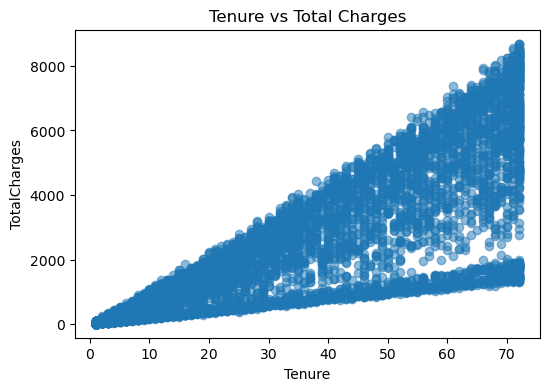

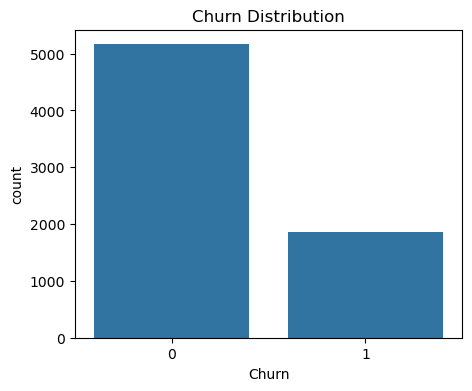

In [9]:
numeric_df = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]
print(numeric_df.corr())
plt.figure(figsize=(6,4))
plt.scatter(df["tenure"], df["TotalCharges"], alpha=0.5)
plt.xlabel("Tenure")
plt.ylabel("TotalCharges")
plt.title("Tenure vs Total Charges")
plt.show()
plt.figure(figsize=(5,4))
sns.countplot(x=df["Churn"])
plt.title("Churn Distribution")
plt.show()

In [10]:
x = df[["tenure", "MonthlyCharges"]]
y = df["TotalCharges"]
print(x.head())
print()
print(y.head())

   tenure  MonthlyCharges
0       1           29.85
1      34           56.95
2       2           53.85
3      45           42.30
4       2           70.70

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (5625, 2)
Testing data shape: (1407, 2)


In [13]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred = linear_model.predict(x_test)
print("Predicted Values:")
print(y_pred[ :5])

Predicted Values:
[2730.75240948  -24.43747265 2352.88227868 2235.5955429  -704.29108296]


In [15]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 score:", r2)

Mean Absolute Error (MAE): 571.089352760724
Mean Squared Error (MSE): 514283.50231658574
Root Mean Squared Error (RMSE): 717.1356233771864
R2 score: 0.9004783340563838


In [16]:
import matplotlib.pyplot as plt

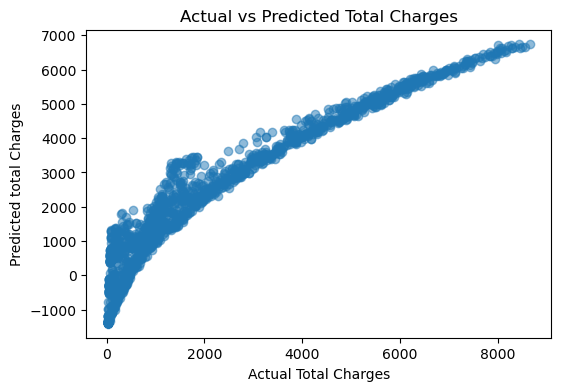

In [17]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Total Charges")
plt.ylabel("Predicted total Charges")
plt.title("Actual vs Predicted Total Charges")
plt.show()

In [18]:
x = df[["tenure", "MonthlyCharges"]]
y = df["Churn"]
print(x.head())
print()
print(y.head())

   tenure  MonthlyCharges
0       1           29.85
1      34           56.95
2       2           53.85
3      45           42.30
4       2           70.70

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [21]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (5274, 2)
Testing data shape: (1758, 2)


In [23]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
print("Feature scaling completed")

Feature scaling completed


In [26]:
logistic_model = LogisticRegression()
logistic_model.fit(x_train, y_train)
print("Logistic Regression model trained sucessfully")

Logistic Regression model trained sucessfully


In [27]:
y_pred = logistic_model.predict(x_test)
print("Predicted classes:")
print(y_pred[:10])

Predicted classes:
[0 0 1 0 0 0 0 1 0 0]


In [28]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print("Accuracy:", accuracy)
print()
print("Confusion Matrix:")
print(cm)
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7775881683731513

Confusion Matrix:
[[1170  130]
 [ 261  197]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1300
           1       0.60      0.43      0.50       458

    accuracy                           0.78      1758
   macro avg       0.71      0.67      0.68      1758
weighted avg       0.76      0.78      0.76      1758



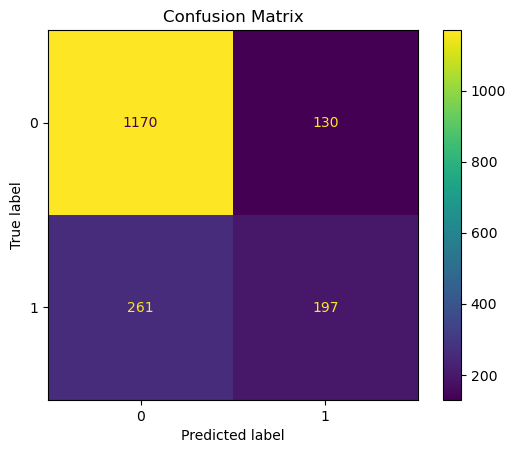

In [31]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()